# S11-2 RFQプライサー（ミニ電子取引エンジン）

## 学習目標

- RFQ（request for quote, 見積依頼）ワークフローの流れを説明し、電子取引の
  クォートエンジンが担う役割を位置づけられる
- ミッド（mid, 仲値）を「NSSカーブのフィット値＋rich/cheap残差」として推定し、
  カーブと個別銘柄の割高割安を分離して価格化できる
- スプレッド（spread, 呼値幅）がサイズ・在庫・ボラティリティの関数として広がる
  仕組みを、在庫リスク（inventory risk）の観点からスクラッチで実装できる
- Avellaneda-Stoikov のリザベーション価格（reservation price, 留保価格）の発想を
  平易に導入し、在庫の偏りに応じてクォートを非対称にスキューできる
- 「銘柄・サイズ・方向を受けて bid/ask を返す」プライサーを実装し、過去データで
  クォートと実勢価格の乖離を統計評価できる

## 実務での位置づけ（ファンドはどう稼ぐか）

このプライサーは、投資銀行の**電子取引・マーケットメイクデスク**が使うクォートエンジンの縮図です。債券は株式のような中央の板を持たず、多くの取引が RFQ（見積依頼）で成立するため、セルサイドのディーラーは顧客の買いに ask で売り・売りに bid で買い、その差（ビッド・オファースプレッド）を収益にします。稼ぎの源泉は「1件ごとのスプレッド × フロー（約定件数）」で、電子化が進んだ今は人手ではなく自動値付けエンジンが秒単位で何百銘柄にクォートを出し続けます。銘柄・サイズ・方向を受けて bid/ask を返す本 notebook のプライサーは、まさにその中核ロジックを最小構成で実装したものです。

稼ぎと損失回避が同居する点が、このデスクの本質です。スプレッドを収益にできる一方、約定のたびに在庫（ポジション）を抱え、価格変動リスクにさらされます。スプレッドを広げれば1件あたりの利ざやは増えますが、他社に負けて約定を取れません。狭めればフローは増えますが、在庫リスクとアドバースセレクション（情報を持つ相手に一方向で当てられる）に負けます。ミッドをカーブフィット値と rich/cheap 残差に分解して個別銘柄の割高割安を織り込むこと、スプレッドをサイズ・在庫・ボラティリティの関数として広げること、そして Avellaneda-Stoikov のリザベーション価格で在庫の偏りに応じてクォートを非対称にスキューすることは、いずれも「取りにいくフロー」と「抱えたくない在庫」を価格で調整する打ち手です。特に在庫スキューは、片側にポジションが積み上がる前に反対側の約定を誘導し、一方向の在庫がもたらす損失を能動的に避けるための仕掛けです。

就職では、電子取引マーケットメイカー（`docs/債券ファンドの業務.md` の対応表で S11-2・S9-4 が効く志望先）に対する直球のアピールになります。過去データでクォートと実勢価格の乖離を統計評価する部分は、実務でいう約定後の値付け精度モニタリングそのものです。「フェアバリューの推定」「在庫リスクの価格化」「約定後の検証」という三点を一気通貫で語れることは、フロー系デスクの面接で強い差別化になります。


## 理論

### RFQ ワークフローとクォートエンジン

債券は株式のような中央集権的な板（オーダーブック）を持たず、多くの取引が
**RFQ**（request for quote, 見積依頼）で成立します。典型的な流れは次のとおりです。

1. 顧客が電子取引プラットフォーム上で「銘柄・サイズ・方向（買い/売り）」を指定し、
   複数ディーラーへ同時に見積を依頼する。
2. 各ディーラーの**クォートエンジン**（quote engine）が、自社のフェアバリュー推定と
   在庫状況から bid（買値）・ask（売値）を自動生成して返す。
3. 顧客は最良気配（最も高い bid、または最も低い ask）を選んで約定する。

ディーラーは**マーケットメイク**（market making, 値付け）を行う立場です。顧客が
買いたいとき ask で売り、売りたいとき bid で買い、bid と ask の差
（**スプレッド**）を収益源とします。同時に、約定のたびに在庫（ポジション）を
抱え、価格変動リスクにさらされます。クォートエンジンの設計とは、
「スプレッドで稼ぐ利益」と「在庫が生む価格リスク」の綱引きを、価格に落とし込む
作業にほかなりません。

### ミッドの推定：カーブ＋rich/cheap残差

bid/ask の中心となる**ミッド**（mid, 仲値）$m_i$ は、銘柄 $i$ のフェアバリューの
推定です。本 notebook では S9-1 の rich/cheap 分析と同じ分解を使います。まず
評価日のユニバース全銘柄に Nelson-Siegel-Svensson（NSS）カーブを最小二乗で
フィットし、モデル利回り $\hat{y}(\tau_i)$ を得ます。次に、銘柄固有の恒常的な
割高割安である **rich/cheap残差** $\bar{r}_i$（時系列平均残差）を足し戻します。

$$ y^{\text{mid}}_i = \hat{y}(\tau_i) + \bar{r}_i $$

カーブは「その日のフェアな期間構造」、残差は「この銘柄が構造的にどれだけ
カーブから外れているか」を表します。両者を足したミッド利回りを、標準的な
クーポン債の価格式で価格へ変換したものがミッド価格 $m_i$ です。カーブだけで
値付けすると、恒常的に cheap な銘柄を高く付けすぎ（在庫を抱えやすく）、
恒常的に rich な銘柄を安く付けすぎます。残差の足し戻しはこの偏りを補正します。

### スプレッドの決定要因：サイズ・在庫・ボラ

ミッドの周りに置く半スプレッド $\delta$（half-spread）は、主に3つの要因で
広がります。

| 要因 | 記号 | スプレッドへの効き方 | 直感 |
|---|---|---|---|
| ボラティリティ | $\sigma$ | $\sigma^2$ に比例して拡大 | 値動きが荒い銘柄ほど在庫の含み損リスクが大きい |
| 取引サイズ | $Q$ | $Q$ に比例して拡大 | 大口を捌くほど積み上がる在庫が大きい |
| 在庫 | $q$ | ミッドを非対称にスキュー | 既に偏った在庫は、増やす側を不利に値付けする |

ボラとサイズは主に**スプレッドの幅**を、在庫は主に**クォートの中心（スキュー）**を
動かします。順に定式化します。

### なぜサイズが大きいとスプレッドを広げるか

サイズ $Q$ の RFQ を約定すると、ディーラーの在庫は $Q$ だけ動きます。この在庫を
反対売買で解消するには時間 $T$ がかかり、その間の価格変動でこうむる損益の分散は、
在庫量の2乗とボラの2乗に比例します。

$$ \operatorname{Var}[\text{在庫の含み損益}] \;\propto\; Q^2\,\sigma^2\,T $$

ディーラーはこのリスクの対価をスプレッドで回収しなければ割に合いません。1単位
あたりで見た**限界的な在庫リスク**は $Q$ に比例して増えるため、半スプレッドは
サイズに対しておおむね線形に広がります。

$$ \delta(Q) \;=\; \underbrace{\delta_0}_{\text{値付けの基礎的な取り分}}
   \;+\; \underbrace{\tfrac{1}{2}\,\gamma\,\sigma^2\,T\,Q}_{\text{サイズに比例する在庫リスク対価}} $$

$\gamma$ はディーラーのリスク回避度です。サイズが10倍になれば右側の第2項も10倍
になり、大口 RFQ ほど広い（不利な）気配が返る、という実務の挙動を再現します。
これは「大口を優遇して狭く出す」直感と逆ですが、値付け側から見ると、大口は
解消しづらい在庫を押し付けられる取引なので、広げるのが合理的です。

### 在庫リスク管理：Avellaneda-Stoikov の発想

在庫が既に偏っているとき、ディーラーは「その偏りをさらに増やす取引」を避け、
「偏りを減らす取引」を歓迎したいはずです。これを価格に織り込むのが
Avellaneda-Stoikov（2008）の**リザベーション価格**（reservation price, 留保価格）
です。現在の在庫を $q$（ロングを正）、ミッドを $m$ として、

$$ r \;=\; m \;-\; q\,\gamma\,\sigma^2\,(T-t) $$

と定義します。ロング在庫（$q>0$）を抱えているとリザベーション価格は
ミッドより低くなり、bid も ask も一緒に押し下がります。すると顧客からの売りは
付きにくく（bid が安い）、買いは付きやすく（ask も安い）なり、在庫が自然に
減る方向へクォートが傾きます。ショート在庫なら逆で、在庫を買い戻す方向へ
傾きます。最適な bid/ask は、このリザベーション価格を中心に半スプレッドを
対称に置いて得ます。

$$ p^{\text{bid}} = r - \delta, \qquad p^{\text{ask}} = r + \delta $$

Avellaneda-Stoikov の原論文では最適スプレッドを
$\delta_a+\delta_b = \gamma\sigma^2(T-t) + \tfrac{2}{\gamma}\ln(1+\gamma/\kappa)$
と導きます（$\kappa$ は注文到達の強度パラメータ）。第1項は在庫リスク、第2項は
注文フローから取れる値付けマージンです。本 notebook では、この構造を保ったまま
サイズ依存の在庫リスク項を明示的に足した、平易化した式を実装します。

用語の対応関係を整理しておきます。**クォート**（quote, 気配）は返す bid/ask の
組、**マーケットメイク**は継続的にクォートを出して両建てで捌く行為、**在庫リスク**
は約定で抱えたポジションの価格変動リスクを指します。

## スクラッチ実装

プライサーを、価格変換・ボラ推定・ミッド推定・クォート生成の部品に分けて
実装します。ミッドは NSS フィット値＋rich/cheap残差、スプレッドはサイズ・在庫・
ボラの関数で、Avellaneda-Stoikov のリザベーション価格でスキューします。

### 使用する自作関数

| 関数 | 引数 | 返り値 | 役割 |
|---|---|---|---|
| `price_from_yield(coupon, years, ytm, freq)` | クーポン率, 残存年数, 利回り, 頻度 | クリーン価格 | 標準クーポン債の YTM→価格（利払日決済を仮定） |
| `modified_duration(coupon, years, ytm, freq)` | 同上 | 修正デュレーション | 価格の利回り感応度 $-\frac{1}{P}\frac{dP}{dy}$ |
| `fit_date_residuals(mat, y, lam_grid)` | 満期配列, 利回り配列, λ格子 | 残差(bp) | 1営業日の NSS フィット残差（S9-1と同一） |
| `build_residual_panel(panel, lam_grid)` | 縦持ちパネル, λ格子 | DataFrame | 全日付の残差パネル（S9-1と同一） |
| `estimate_daily_vol(panel)` | 縦持ちパネル | Series(bond→σ_y) | 銘柄ごとの日次利回り変化の標準偏差 |
| `RFQPricer` | ユニバース, 評価日カーブ, 残差, ボラ, パラメータ | — | 銘柄・サイズ・方向・在庫→ bid/ask を返す本体 |

In [1]:
import os

os.environ.setdefault("MPLBACKEND", "Agg")

from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["Hiragino Sans", "Yu Gothic", "Meiryo", "IPAexGothic", "Noto Sans CJK JP", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
from bondlab.curve import fit_nss, nss

np.random.seed(0)

# λ格子は粗く取る。既定の 20x20 格子は日次ループでは重いため、8 点に絞る
# （S9-1 と同じ方針。残差の相対順位はこの粗さでも安定する）。
LAM_GRID = np.linspace(0.8, 8.0, 8)
BP = 1e4  # 小数利回り → ベーシスポイント
FREQ = 2  # 半年利払いを仮定


def price_from_yield(coupon, years, ytm, freq=FREQ, face=100.0):
    """半年利払いの標準クーポン債を、利払日決済（経過利子ゼロ）で価格化する。

    残存を整数期間 n=round(years*freq) とみなし、各期のクーポンと満期の額面を
    y/f で割り引いた合計を返す。ytm=coupon のとき価格は額面（パー）に一致する。
    """
    n = int(round(years * freq))
    n = max(n, 1)
    c = coupon / freq * face
    y = ytm / freq
    disc = (1.0 + y) ** (-np.arange(1, n + 1))
    return float(c * disc.sum() + face * disc[-1])


def modified_duration(coupon, years, ytm, freq=FREQ, face=100.0, h=1e-4):
    """修正デュレーション $D=-\\frac{1}{P}\\frac{dP}{dy}$ を中心差分で数値近似する。

    利回りを ±h だけ動かした価格から傾きを取り、価格で規格化する。価格ボラを
    利回りボラから作る（σ_P ≈ D·P·σ_y）ために使う。
    """
    p0 = price_from_yield(coupon, years, ytm, freq, face)
    p_up = price_from_yield(coupon, years, ytm + h, freq, face)
    p_dn = price_from_yield(coupon, years, ytm - h, freq, face)
    dpdy = (p_up - p_dn) / (2.0 * h)
    return -dpdy / p0


def fit_date_residuals(mat, y, lam_grid=LAM_GRID):
    """1営業日の (満期, 利回り) に NSS をフィットし、残差(bp)を返す（S9-1と同一）。

    残差 = 実測利回り - モデル利回り。正なら利回りが高く価格が安い=cheap。
    """
    mat = np.asarray(mat, dtype=float)
    y = np.asarray(y, dtype=float)
    fit = fit_nss(mat, y, lam_grid=lam_grid)
    return (y - nss(mat, **fit)) * BP


def build_residual_panel(panel, lam_grid=LAM_GRID):
    """縦持ちパネルから残差パネル DataFrame(index=date, columns=bond_id) を作る。"""
    rows = {}
    for date, grp in panel.groupby("date"):
        grp = grp.sort_values("maturity_years")
        resid = fit_date_residuals(grp["maturity_years"].values, grp["yield"].values, lam_grid)
        rows[date] = pd.Series(resid, index=grp["bond_id"].values)
    wide = pd.DataFrame(rows).T
    wide.index = pd.to_datetime(wide.index)
    return wide.sort_index()


def estimate_daily_vol(panel):
    """銘柄ごとに、日次利回り変化の標準偏差 σ_y（小数）を推定する。

    パネルを日付×銘柄のワイド表に直し、差分の標準偏差を列ごとに取る。値動きの
    荒い銘柄ほど σ_y が大きく、スプレッドを広げる要因になる。
    """
    wide = panel.pivot(index="date", columns="bond_id", values="yield").sort_index()
    return wide.diff().std(axis=0, ddof=1)

### プライサー本体

`RFQPricer` は評価日のスナップショットから、各銘柄のミッド価格・価格ボラ・
修正デュレーションを前計算し、`quote()` で銘柄・サイズ・方向・在庫を受けて
bid/ask を返します。半スプレッドとリザベーション価格は理論節の式に従います。

- ミッド価格 $m_i$ = `price_from_yield(coupon, 残存, ŷ(τ_i)+r̄_i)`
- 価格ボラ $\sigma^P_i$ ≈ $D_i \cdot m_i \cdot \sigma^y_i$（利回りボラを価格ボラへ）
- 半スプレッド $\delta = \delta_0 + \tfrac{1}{2}\gamma (\sigma^P)^2 T\,Q$
- リザベーション価格 $r = m - q\,\gamma (\sigma^P)^2 (T-t)$
- 気配 $p^{\text{bid}} = r-\delta,\; p^{\text{ask}} = r+\delta$

`side`（方向）は顧客から見た売買です。顧客の買いは ask、売りは bid で約定します。
約定するとディーラー在庫は反対方向へ動く（顧客が買えばディーラーはショートを
増やす）ため、`fill_inventory_delta()` で約定後の在庫変化も返します。

In [2]:
@dataclass
class RFQParams:
    """プライサーの調整パラメータ。値は説明用に設定した水準で、実務では
    約定履歴からキャリブレーションする。"""
    gamma: float = 0.15     # リスク回避度（大きいほど在庫を嫌いスプレッド拡大・スキュー強）
    kappa: float = 1.3      # 注文到達の強度（大きいほど基礎スプレッドは縮む）
    horizon: float = 5.0    # 在庫解消までの想定日数 (T-t)
    base_ticks: float = 0.02  # 最低半スプレッド（価格の下限フロア）


class RFQPricer:
    """評価日スナップショットから RFQ の bid/ask を生成するミニ・クォートエンジン。"""

    def __init__(self, universe, snap_yields, resid_mean_bp, daily_vol, params=None):
        """
        universe : DataFrame(bond_id, maturity_years, coupon, ...)
        snap_yields : Series(bond_id -> 評価日の実測利回り)
        resid_mean_bp : Series(bond_id -> 時系列平均残差 bp = rich/cheap)
        daily_vol : Series(bond_id -> 日次利回り変化の標準偏差 σ_y)
        """
        self.params = params or RFQParams()
        self.univ = universe.set_index("bond_id")
        # 評価日カーブを全銘柄にフィットし、モデル利回りを得る
        mat = self.univ["maturity_years"].reindex(snap_yields.index).values
        fit = fit_nss(mat, snap_yields.values, lam_grid=LAM_GRID)
        model_y = pd.Series(nss(mat, **fit), index=snap_yields.index)
        self._fit = fit
        # ミッド利回り = カーブ + rich/cheap残差、ミッド価格へ変換
        resid_y = resid_mean_bp.reindex(snap_yields.index) / BP
        self.mid_yield = model_y + resid_y
        recs = {}
        for b in snap_yields.index:
            cpn = self.univ.loc[b, "coupon"]
            yrs = self.univ.loc[b, "maturity_years"]
            my = self.mid_yield[b]
            m = price_from_yield(cpn, yrs, my)
            dur = modified_duration(cpn, yrs, my)
            sig_p = dur * m * daily_vol.get(b, np.nan)  # 価格ボラ（1日あたり）
            recs[b] = dict(mid=m, dur=dur, sigma_p=sig_p, mid_yield=my)
        self.book = pd.DataFrame(recs).T

    def half_spread(self, bond_id, size):
        """半スプレッド δ = δ0 + 0.5·γ·(σ_P)^2·T·Q。サイズ Q に線形に広がる。"""
        p = self.params
        sig_p = self.book.loc[bond_id, "sigma_p"]
        inv_risk = 0.5 * p.gamma * sig_p ** 2 * p.horizon * size
        return p.base_ticks + inv_risk

    def reservation(self, bond_id, inventory):
        """リザベーション価格 r = mid - q·γ·(σ_P)^2·(T-t)。在庫でミッドをスキュー。"""
        p = self.params
        m = self.book.loc[bond_id, "mid"]
        sig_p = self.book.loc[bond_id, "sigma_p"]
        return m - inventory * p.gamma * sig_p ** 2 * p.horizon

    def quote(self, bond_id, size=1.0, side="two_way", inventory=0.0):
        """銘柄・サイズ・方向・在庫を受けて bid/ask を返す。

        side: "two_way"（両面）/ "client_buy"（顧客買い→ask約定）/ "client_sell"（顧客売り→bid約定）。
        返り値の fill_price は方向が片面のとき顧客の約定価格、両面なら None。
        """
        r = self.reservation(bond_id, inventory)
        d = self.half_spread(bond_id, size)
        bid = r - d
        ask = r + d
        fill = None
        inv_delta = 0.0
        if side == "client_buy":
            fill = ask               # 顧客は ask で買う
            inv_delta = -size        # ディーラーは売ってショートを増やす
        elif side == "client_sell":
            fill = bid               # 顧客は bid で売る
            inv_delta = +size        # ディーラーは買ってロングを増やす
        return dict(
            bond_id=bond_id, mid=self.book.loc[bond_id, "mid"], reservation=r,
            bid=bid, ask=ask, half_spread=d, size=size, side=side,
            fill_price=fill, fill_inventory_delta=inv_delta,
        )

データを読み込み、残差パネル・ボラ・評価日スナップショットを用意してプライサーを
組み立てます。評価日は直近営業日とします。

In [3]:
universe = pd.read_csv("data/samples/synthetic_jgb_universe.csv")
panel = pd.read_csv("data/samples/synthetic_jgb_yield_panel.csv")

resid_panel = build_residual_panel(panel)
resid_mean_bp = resid_panel.mean(axis=0)           # rich/cheap（時系列平均残差 bp）
daily_vol = estimate_daily_vol(panel)              # σ_y（日次利回り変化）

val_date = panel["date"].max()
snap = panel[panel["date"] == val_date].set_index("bond_id")
snap_yields = snap["yield"]

pricer = RFQPricer(universe, snap_yields, resid_mean_bp, daily_vol)

print("評価日:", val_date, " 銘柄数:", len(snap_yields))
print("\nプライサー内部テーブル 先頭5銘柄:")
display(pricer.book.head().round(4))

評価日: 2026-03-26  銘柄数: 40

プライサー内部テーブル 先頭5銘柄:


,mid,dur,sigma_p,mid_yield
JGB000,99.2075,1.4886,0.1312,0.0103
JGB001,99.0332,2.4616,0.2140,0.0129
JGB002,98.9603,2.9376,0.2558,0.0146
JGB003,98.9247,4.3510,0.3798,0.0155
JGB004,99.9061,4.3246,0.3710,0.0162


1銘柄に対して両面クォートを出してみます。bid < mid < ask になり、在庫ゼロなら
リザベーション価格はミッドに一致します。

In [4]:
b0 = snap_yields.index[10]
q = pricer.quote(b0, size=1.0, side="two_way", inventory=0.0)
print(f"銘柄 {b0} の両面クォート（在庫0・サイズ1）:")
for k in ["mid", "reservation", "bid", "ask", "half_spread"]:
    print(f"  {k:12s} = {q[k]:.4f}")
assert q["bid"] < q["mid"] < q["ask"], "bid<mid<ask が崩れている"
assert abs(q["reservation"] - q["mid"]) < 1e-12, "在庫0でリザベーションがミッドから外れた"
print("チェック通過: bid < mid < ask、在庫0でリザベーション=ミッド")

銘柄 JGB010 の両面クォート（在庫0・サイズ1）:
  mid          = 97.8811
  reservation  = 97.8811
  bid          = 97.7565
  ask          = 98.0056
  half_spread  = 0.1245
チェック通過: bid < mid < ask、在庫0でリザベーション=ミッド


## QuantLib検証

RFQ クォートエンジンは「フェアバリュー推定＋在庫リスクに応じた値付け」であり、
QuantLib はこの**マーケットメイクの値付けロジックに対応する部品を持ちません**
（S9-1 で NSS フィットが QuantLib の守備範囲外だったのと同じ事情です）。
そこで検証は次の2段構えで行い、**その位置づけを明記**します。

- **検証A（部品の正しさ）**: ミッド価格の土台である `price_from_yield` を、
  QuantLib と突合済みの参照実装 `bondlab.bond.FixedRateBond` と一致させて確かめる。
- **検証B（クォートの妥当性）**: 過去データでクォートのミッドと**実勢価格**の
  乖離を統計評価する。これは「実装が実勢を再現できているか」の健全性検査であって、
  将来の収益を保証するものではない、という位置づけを明記する。

### 検証A：価格式を bondlab.bond と突合

利払日決済・整数残存の条件下では、自作の `price_from_yield` は
`bondlab.bond.FixedRateBond.clean_price` と一致するはずです。

In [5]:
import datetime as dt

from bondlab.bond import FixedRateBond

issue = dt.date(2026, 6, 15)
maturity = dt.date(2036, 6, 15)      # 10年・整数期間
settle = dt.date(2026, 6, 15)        # 利払日決済 → 経過利子ゼロ
ref = FixedRateBond(issue=issue, maturity=maturity, coupon=0.02, frequency=FREQ)
ref_clean = ref.clean_price(0.015, settle)
mine = price_from_yield(0.02, 10.0, 0.015, FREQ)
print(f"bondlab.FixedRateBond clean = {ref_clean:.10f}")
print(f"自作 price_from_yield        = {mine:.10f}")
assert abs(ref_clean - mine) < 1e-6, "参照実装と価格が一致しない"
# パー条件と往復（価格→利回り→価格）も確認する
assert abs(price_from_yield(0.02, 10.0, 0.02) - 100.0) < 1e-8, "パー条件が崩れた"
print("検証A 合格: 価格式が参照実装・パー条件と整合")

bondlab.FixedRateBond clean = 104.6270049234
自作 price_from_yield        = 104.6270049234
検証A 合格: 価格式が参照実装・パー条件と整合


### 検証B：クォートのミッド vs 実勢価格の乖離

各銘柄について、プライサーのミッド価格（カーブ＋rich/cheap残差）と、評価日の
**実勢価格**（その日の実測利回りから価格化した値）の乖離を集計します。ミッドは
恒常的な残差 $\bar{r}_i$ を使うため、実勢とは「その日だけの一時的な残差」の分だけ
ずれます。乖離が小さく偏りが無いことは、値付けの中心が実勢に整合している健全性の
目安になります（収益の保証ではありません）。

In [6]:
actual_price = snap_yields.copy()
mids = pricer.book["mid"]
rows = []
for b in snap_yields.index:
    cpn = universe.set_index("bond_id").loc[b, "coupon"]
    yrs = universe.set_index("bond_id").loc[b, "maturity_years"]
    px_actual = price_from_yield(cpn, yrs, snap_yields[b])
    rows.append({"bond_id": b, "mid": mids[b], "actual": px_actual,
                 "dev": mids[b] - px_actual})
dev_df = pd.DataFrame(rows).set_index("bond_id")

print("クォートのミッド − 実勢価格 の統計（価格点）:")
display(dev_df["dev"].describe().round(4))
print(f"\n平均乖離 (bias): {dev_df['dev'].mean():+.4f} 点")
print(f"乖離の RMSE     : {np.sqrt((dev_df['dev'] ** 2).mean()):.4f} 点")
# ミッドは実勢を概ね再現し、系統的な偏りは小さいはず
assert abs(dev_df["dev"].mean()) < 0.5, "ミッドが実勢から系統的に偏っている"
print("検証B 合格: ミッドが実勢価格を偏り小さく再現（健全性検査）")

クォートのミッド − 実勢価格 の統計（価格点）:


count    40.0000
mean     -0.0000
std       0.0573
min      -0.1809
25%      -0.0305
50%      -0.0002
75%       0.0252
max       0.1457
Name: dev, dtype: float64


平均乖離 (bias): -0.0000 点
乖離の RMSE     : 0.0565 点
検証B 合格: ミッドが実勢価格を偏り小さく再現（健全性検査）


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


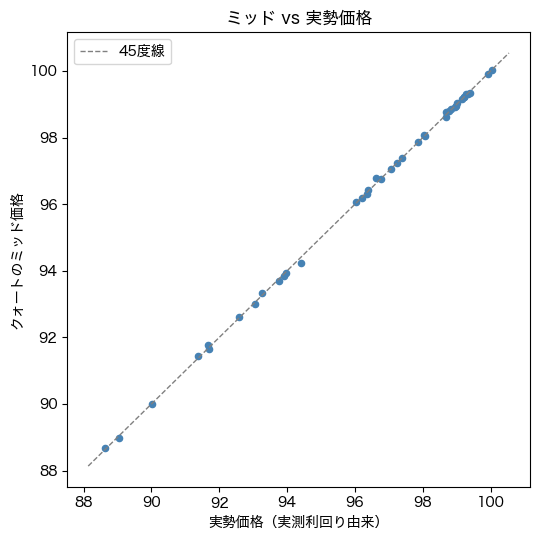

In [7]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(dev_df["actual"], dev_df["mid"], s=20, color="steelblue")
lim = [dev_df[["actual", "mid"]].min().min() - 0.5,
       dev_df[["actual", "mid"]].max().max() + 0.5]
ax.plot(lim, lim, color="gray", lw=1, ls="--", label="45度線")
ax.set_xlabel("実勢価格（実測利回り由来）")
ax.set_ylabel("クォートのミッド価格")
ax.set_title("ミッド vs 実勢価格")
ax.legend()
fig.tight_layout()
plt.show()

## 実データ適用

### サイズ10倍の RFQ にどうスプレッドを広げるか

同じ銘柄・同じ在庫（ゼロ）で、標準サイズと10倍サイズの RFQ を比べます。理論節の
とおり、半スプレッドはサイズに比例する在庫リスク項を持つため、大口ほど広い
（顧客に不利な）気配になります。在庫リスクの観点では、10倍の在庫を解消するまでの
価格変動リスクは10倍で、その対価をスプレッドで回収する設計です。

In [8]:
target = snap_yields.index[10]
base_size = 1.0
big_size = 10.0

qs = pricer.quote(target, size=base_size, inventory=0.0)
qb = pricer.quote(target, size=big_size, inventory=0.0)

comp = pd.DataFrame([
    {"サイズ": base_size, "bid": qs["bid"], "ask": qs["ask"],
     "スプレッド幅": qs["ask"] - qs["bid"], "半スプレッド": qs["half_spread"]},
    {"サイズ": big_size, "bid": qb["bid"], "ask": qb["ask"],
     "スプレッド幅": qb["ask"] - qb["bid"], "半スプレッド": qb["half_spread"]},
])
print(f"銘柄 {target} のサイズ別クォート（在庫0）:")
display(comp.round(4))
widen = (qb["ask"] - qb["bid"]) / (qs["ask"] - qs["bid"])
print(f"\nスプレッド幅は 10倍サイズで {widen:.2f} 倍に拡大")
assert (qb["ask"] - qb["bid"]) > (qs["ask"] - qs["bid"]), "大口でスプレッドが広がっていない"

銘柄 JGB010 のサイズ別クォート（在庫0）:


,サイズ,bid,ask,スプレッド幅,半スプレッド
0,1.0,97.7565,98.0056,0.2491,0.1245
1,10.0,96.8157,98.9464,2.1306,1.0653



スプレッド幅は 10倍サイズで 8.55 倍に拡大


半スプレッドをサイズの関数として描くと、基礎スプレッド $\delta_0$ を切片に、
サイズに対して線形に立ち上がることが見えます。傾きは価格ボラの2乗
$(\sigma^P)^2$ に比例し、値動きの荒い銘柄ほど急になります。

findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


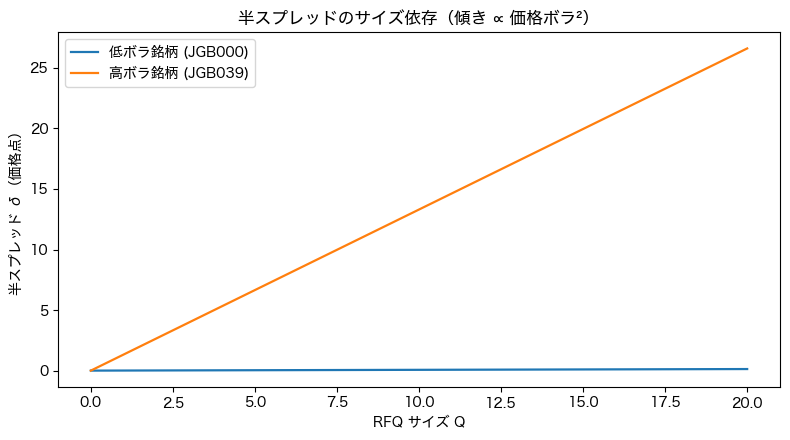

In [9]:
sizes = np.linspace(0, 20, 41)
fig, ax = plt.subplots(figsize=(8, 4.5))
for bid_label, bond_id in [("低ボラ銘柄", pricer.book["sigma_p"].idxmin()),
                           ("高ボラ銘柄", pricer.book["sigma_p"].idxmax())]:
    hs = [pricer.half_spread(bond_id, s) for s in sizes]
    ax.plot(sizes, hs, lw=1.6, label=f"{bid_label} ({bond_id})")
ax.set_xlabel("RFQ サイズ Q")
ax.set_ylabel("半スプレッド δ（価格点）")
ax.set_title("半スプレッドのサイズ依存（傾き ∝ 価格ボラ²）")
ax.legend()
fig.tight_layout()
plt.show()

### 在庫リスクをクォートに反映する

在庫を偏らせると、リザベーション価格がミッドから離れ、bid/ask が一斉にスキュー
します。ロング在庫では気配が下がり、顧客の買い（在庫が減る）を付きやすく、売り
（在庫が増える）を付きにくくします。これが在庫を平常水準へ戻す圧力になります。

findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


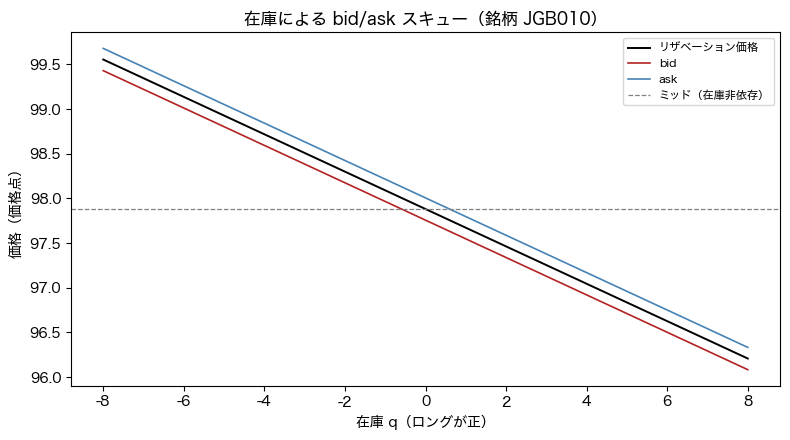

在庫スキュー確認: ロング在庫でリザベーション価格が低下（在庫を減らす方向）


In [10]:
inv_grid = np.linspace(-8, 8, 33)
mid_line = pricer.book.loc[target, "mid"]
res_line = [pricer.reservation(target, q) for q in inv_grid]
bid_line = [pricer.quote(target, size=1.0, inventory=q)["bid"] for q in inv_grid]
ask_line = [pricer.quote(target, size=1.0, inventory=q)["ask"] for q in inv_grid]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(inv_grid, res_line, color="black", lw=1.4, label="リザベーション価格")
ax.plot(inv_grid, bid_line, color="firebrick", lw=1.2, label="bid")
ax.plot(inv_grid, ask_line, color="steelblue", lw=1.2, label="ask")
ax.axhline(mid_line, color="gray", ls="--", lw=0.9, label="ミッド（在庫非依存）")
ax.set_xlabel("在庫 q（ロングが正）")
ax.set_ylabel("価格（価格点）")
ax.set_title(f"在庫による bid/ask スキュー（銘柄 {target}）")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

# 在庫が増えるほどリザベーション価格は単調に下がるはず
assert res_line[0] > res_line[-1], "在庫スキューの向きが逆"
print("在庫スキュー確認: ロング在庫でリザベーション価格が低下（在庫を減らす方向）")

### 大口 RFQ を在庫リスク込みで捌く一連の流れ

「サイズ10倍の買い RFQ を、既にロング在庫がある状態で受ける」局面を通します。
サイズによるスプレッド拡大（在庫リスクの対価）と、既存在庫によるスキュー
（偏りを増やす側を不利に）が同時に効きます。

In [11]:
scenario = pricer.quote(target, size=10.0, side="client_buy", inventory=4.0)
base = pricer.quote(target, size=1.0, side="client_buy", inventory=0.0)
print("局面: 既存ロング在庫 +4、顧客から10倍サイズの買い RFQ")
print(f"  基準（在庫0・サイズ1）の ask   = {base['ask']:.4f}")
print(f"  当該局面の ask                 = {scenario['ask']:.4f}")
print(f"  → ミッド {scenario['mid']:.4f} に対し、"
      f"サイズと在庫の分だけ ask を調整")
print(f"  約定後の在庫変化 = {scenario['fill_inventory_delta']:+.0f}"
      f"（顧客の買いでディーラーはショートを増やし、在庫が中立へ向かう）")

局面: 既存ロング在庫 +4、顧客から10倍サイズの買い RFQ
  基準（在庫0・サイズ1）の ask   = 98.0056
  当該局面の ask                 = 98.1101
  → ミッド 97.8811 に対し、サイズと在庫の分だけ ask を調整
  約定後の在庫変化 = -10（顧客の買いでディーラーはショートを増やし、在庫が中立へ向かう）


## 演習

1. **サイズ・在庫を変えて bid/ask を可視化**：ある銘柄を1つ選び、在庫を
   $q\in\{-5,0,+5\}$ の3通り、サイズを 1〜15 で動かして bid と ask を描け。
   在庫がスプレッドの「中心」を、サイズが「幅」を動かすという役割分担が図から
   読み取れることを確認し、一言で説明せよ。
2. **Avellaneda-Stoikov 風のリザベーション価格シフト**：時間の経過とともに在庫
   解消の残り時間 $(T-t)$ が縮む効果を実装せよ。`reservation()` の $(T-t)$ を
   $T$ 固定から「残り時間」に置き換え、$t=0\to T$ でリザベーション価格の
   スキュー幅がゼロへ収束していく様子をプロットせよ。満期（在庫解消期限）が
   近いほどスキューが弱まる理由を、在庫リスクの観点から述べよ。

解答例は `solutions/S11/sol_1102.py` にある。

## 付録：FastAPI 化（関数定義のみ・サーバは起動しない）

電子取引では、このプライサーを HTTP エンドポイントとして公開し、プラット
フォームからの RFQ を受けます。実体は `app/rfq_pricer.py` にあり、`/quote` に
銘柄・サイズ・方向・在庫を POST すると bid/ask を返します。本 notebook では
**サーバは起動せず**、ロジックが notebook のプライサーと同型であることだけを
確認します。起動方法は次のとおりです（実行しません）。

```bash
pip install fastapi uvicorn
uvicorn app.rfq_pricer:app --reload
# 例: curl -X POST localhost:8000/quote \
#   -H 'Content-Type: application/json' \
#   -d '{"bond_id":"JGB010","size":10,"side":"client_buy","inventory":4}'
```

ここでは純粋関数版のクォート計算を再掲し、上のクラスと同じ bid/ask を返すことを
確認します。

In [12]:
def quote_core(mid, sigma_p, inventory, size, gamma=0.15, kappa=1.3,
               horizon=5.0, base_ticks=0.02):
    """クラスに依存しない純粋関数版のクォート計算（app 側と同一ロジック）。"""
    reservation = mid - inventory * gamma * sigma_p ** 2 * horizon
    half = base_ticks + 0.5 * gamma * sigma_p ** 2 * horizon * size
    return dict(mid=mid, reservation=reservation,
                bid=reservation - half, ask=reservation + half, half_spread=half)


row = pricer.book.loc[target]
core = quote_core(row["mid"], row["sigma_p"], inventory=4.0, size=10.0)
cls = pricer.quote(target, size=10.0, inventory=4.0)
print("純粋関数版とクラス版の一致確認:")
print(f"  bid  純関数 {core['bid']:.6f} / クラス {cls['bid']:.6f}")
print(f"  ask  純関数 {core['ask']:.6f} / クラス {cls['ask']:.6f}")
assert abs(core["bid"] - cls["bid"]) < 1e-9 and abs(core["ask"] - cls["ask"]) < 1e-9
print("一致: app/rfq_pricer.py はこの純粋関数版を FastAPI で包む")

純粋関数版とクラス版の一致確認:
  bid  純関数 95.979490 / クラス 95.979490
  ask  純関数 98.110114 / クラス 98.110114
一致: app/rfq_pricer.py はこの純粋関数版を FastAPI で包む


## 用語集

定義の正は `glossary/09_trading.md`。ここでは初出語の一行要約のみ示す。

| 用語 | 英語 | 一行定義 |
|---|---|---|
| RFQ | request for quote | 銘柄・サイズ・方向を指定して複数ディーラーへ気配を求める見積依頼方式 |
| ミッド | mid | bid/ask の中心となるフェアバリュー推定。ここではカーブ＋rich/cheap残差 |
| クォート | quote | ディーラーが返す bid（買値）・ask（売値）の組 |
| マーケットメイク | market making | 継続的に両面クォートを出し、スプレッドで稼ぎつつ在庫を捌く行為 |
| 在庫リスク | inventory risk | 約定で抱えたポジションの価格変動リスク。サイズとボラで拡大 |